In [ ]:
from google.colab import files
files.upload()  # Upload kaggle.json

import os
# Create the Kaggle config directory
os.makedirs("/root/.kaggle", exist_ok=True)
# Move kaggle.json to the correct directory
!mv kaggle.json /root/.kaggle/kaggle.json
# Set permission to avoid access errors
!chmod 600 /root/.kaggle/kaggle.json


Saving kaggle.json to kaggle.json


In [ ]:
# Downloading the dataset
!kaggle datasets download -d mrwellsdavid/unsw-nb15


Dataset URL: https://www.kaggle.com/datasets/mrwellsdavid/unsw-nb15
License(s): unknown
 58% 86.0M/149M [00:00<00:00, 900MB/s]
100% 149M/149M [00:00<00:00, 684MB/s] 


In [ ]:
import zipfile

with zipfile.ZipFile("unsw-nb15.zip", 'r') as zip_ref:
    zip_ref.extractall("unsw-nb15")


In [ ]:
import pandas as pd
#Read CSV files into pandas DataFrames
train_df = pd.read_csv("unsw-nb15/UNSW_NB15_training-set.csv")
test_df = pd.read_csv("unsw-nb15/UNSW_NB15_testing-set.csv")
#showing first 5 rows of training set
train_df.head(8232)


,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.000011,udp,-,INT,2,0,496,0,90909.090200,...,1,2,0,0,0,1,2,0,Normal,0
1,2,0.000008,udp,-,INT,2,0,1762,0,125000.000300,...,1,2,0,0,0,1,2,0,Normal,0
2,3,0.000005,udp,-,INT,2,0,1068,0,200000.005100,...,1,3,0,0,0,1,3,0,Normal,0
3,4,0.000006,udp,-,INT,2,0,900,0,166666.660800,...,1,3,0,0,0,2,3,0,Normal,0
4,5,0.000010,udp,-,INT,2,0,2126,0,100000.002500,...,1,3,0,0,0,2,3,0,Normal,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8227,8228,0.000003,unas,-,INT,2,0,200,0,333333.321500,...,3,7,0,0,0,3,7,0,Exploits,1
8228,8229,1.926782,tcp,smtp,FIN,22,20,3529,1680,21.279003,...,1,1,0,0,0,3,1,0,Exploits,1
8229,8230,0.000003,unas,-,INT,2,0,200,0,333333.321500,...,4,9,0,0,0,13,9,0,DoS,1
8230,8231,0.000009,ib,-,INT,2,0,200,0,111111.107200,...,2,7,0,0,0,2,7,0,DoS,1


In [ ]:
# Check how many missing values are in each column
print(" Missing Values in Each Column:")
train_df.isnull().sum().sort_values(ascending=False).head(5)


 Missing Values in Each Column:


,0
id,0
dur,0
proto,0
service,0
state,0


In [ ]:
#Show overall dataset info
print("Dataset Info:")
train_df.info()

#Show dataset dimensions (rows x columns)
print("\n Dataset Shape:")
# Print the number of rows and columns in the dataset using the shape attribute
print(f"Rows: {train_df.shape[0]}, Columns: {train_df.shape[1]}")

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 82332 entries, 0 to 82331
Data columns (total 45 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 82332 non-null  int64  
 1   dur                82332 non-null  float64
 2   proto              82332 non-null  object 
 3   service            82332 non-null  object 
 4   state              82332 non-null  object 
 5   spkts              82332 non-null  int64  
 6   dpkts              82332 non-null  int64  
 7   sbytes             82332 non-null  int64  
 8   dbytes             82332 non-null  int64  
 9   rate               82332 non-null  float64
 10  sttl               82332 non-null  int64  
 11  dttl               82332 non-null  int64  
 12  sload              82332 non-null  float64
 13  dload              82332 non-null  float64
 14  sloss              82332 non-null  int64  
 15  dloss              82332 non-null  int64  
 16  sinpkt  

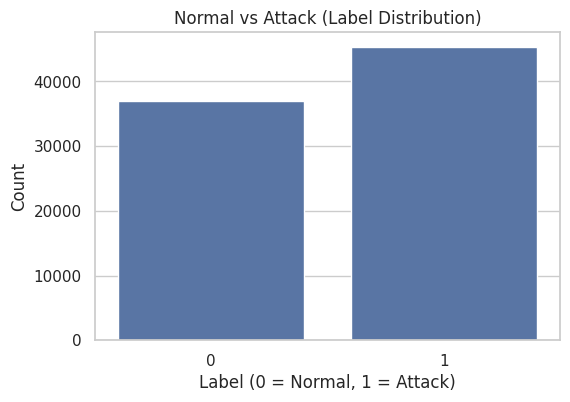


 Class Distribution (label):
label
1    45332
0    37000
Name: count, dtype: int64


In [ ]:
# Target Variable Distribution (Normal vs Attack traffic's)

import seaborn as sns
import matplotlib.pyplot as plt

#Plot count of Normal vs Attack labels
sns.set(style="whitegrid")
plt.figure(figsize=(6,4))
sns.countplot(x='label', data=train_df)
plt.title("Normal vs Attack (Label Distribution)")
plt.xlabel("Label (0 = Normal, 1 = Attack)")
plt.ylabel("Count")
plt.show()

#Show exact counts
print("\n Class Distribution (label):")
print(train_df['label'].value_counts())


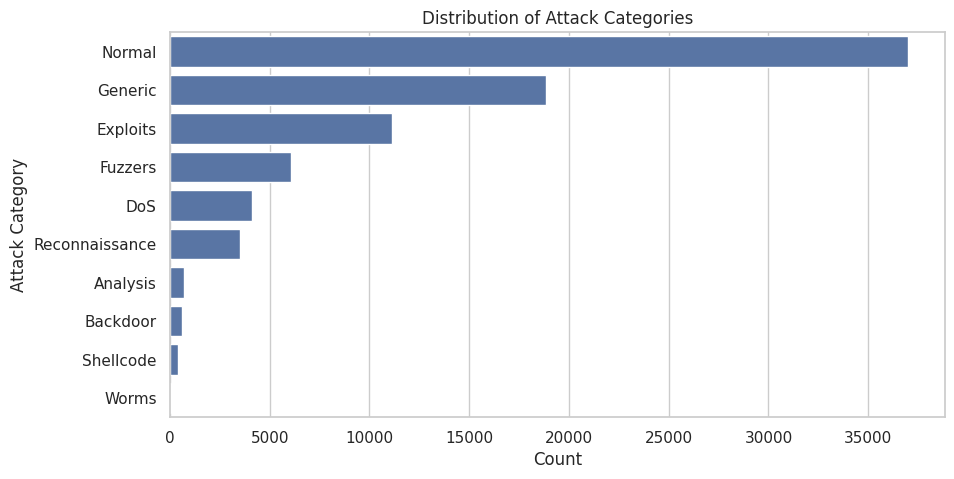


 Attack Categories:
attack_cat
Normal            37000
Generic           18871
Exploits          11132
Fuzzers            6062
DoS                4089
Reconnaissance     3496
Analysis            677
Backdoor            583
Shellcode           378
Worms                44
Name: count, dtype: int64


In [ ]:
# Plot distribution of attack categories if the coloumn exists
if 'attack_cat' in train_df.columns:
    plt.figure(figsize=(10,5))

# Plot a horizontal bar chart showing the frequency of each attack category
    sns.countplot(y='attack_cat',data=train_df, order=train_df['attack_cat'].value_counts().index)
    plt.title("Distribution of Attack Categories")
    plt.xlabel("Count")
    plt.ylabel("Attack Category")
    plt.show()

#Show attack counts
print("\n Attack Categories:")
print(train_df['attack_cat'].value_counts())


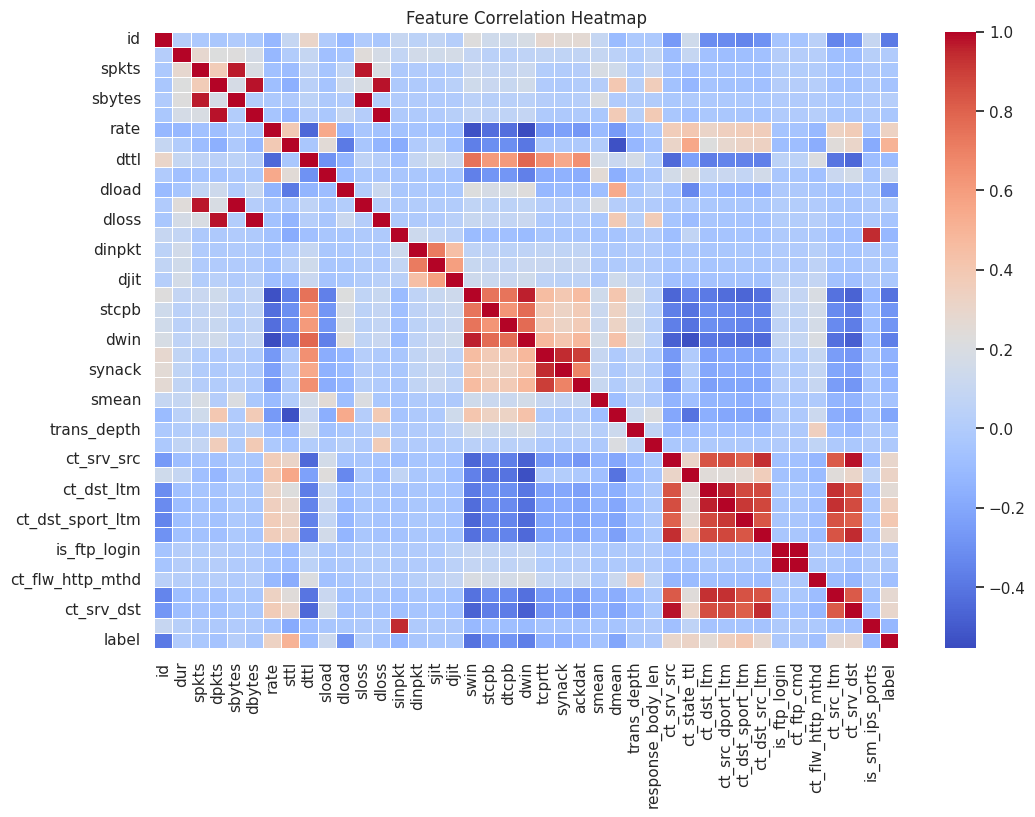

In [ ]:
# Correlation Heatmap

#Select all numeric columns from the dataset (excluding object/string columns)

numeric_cols = train_df.select_dtypes(include='number').columns

#Compute the correlation matrix between all numeric columns
corr_matrix = train_df[numeric_cols].corr()

#Set the figure size for the heatmap plot
plt.figure(figsize=(12,8))

#Draw a heatmap to visualize feature correlations
sns.heatmap(corr_matrix, cmap="coolwarm", linewidths=0.5)

#Set a title for the plot and disply it
plt.title("Feature Correlation Heatmap")
plt.show()


In [ ]:
# Top Features Correlated with Target
label_corr = corr_matrix['label'].drop('label').sort_values(ascending=False)

#Get correlations of all features with the 'label' column
print("Top 5 Features Positively Correlated with 'label':")

#Print the top 5 features that are most positively correlated with attacks (label = 1)
print(label_corr.head(3))

# Print the top 5 features most negatively correlated with attack
print("\n Top 5 Features Negatively Correlated with 'label':")
print(label_corr.tail(3))


Top 5 Features Positively Correlated with 'label':
sttl                0.504159
ct_dst_sport_ltm    0.393668
ct_src_dport_ltm    0.341513
Name: label, dtype: float64

 Top 5 Features Negatively Correlated with 'label':
dwin   -0.369257
id     -0.387489
swin   -0.414504
Name: label, dtype: float64
